# Task 6 — PubChem Screening

**Goal:** Fetch novel BRAF V600E-related compounds from PubChem, train a screening SVC on RDKit-computable features derived from the same 243 training compounds, and identify new predicted inhibitors.

**Why a separate screening model?**  
The Task 4 SVC was trained on MOE-computed descriptors (AM1, vsurf, PEOE, etc.) that require commercial software and cannot be computed for arbitrary new compounds. RDKit is open-source and can compute Morgan fingerprints and physicochemical descriptors for any SMILES string, making it suitable for screening at scale.

**Input:** `data/processed/compounds_clean.csv`, `data/processed/y.npy`  
**Output:** `results/predictions/screening_predictions.csv`

In [12]:
import numpy as np
import pandas as pd
import requests
import time
import sys
import os

from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline

# Add project root to path so src/ modules are importable
sys.path.append(os.path.abspath('..'))

PUBCHEM_BASE = 'https://pubchem.ncbi.nlm.nih.gov/rest/pug'
pd.set_option('display.float_format', '{:.4f}'.format)

## 1. Fetch SMILES for Training Compounds

Our training data contains PubChem CIDs but no SMILES. We retrieve SMILES from PubChem so RDKit can compute features for the same 243 compounds, creating a training set for the screening model.

In [13]:
df = pd.read_csv('../data/processed/compounds_clean.csv')
y  = np.load('../data/processed/y.npy')
training_cids = df['CID'].tolist()

def fetch_smiles(cids: list, batch_size: int = 100) -> dict:
    """Fetch SMILES from PubChem in batches to respect API limits."""
    result = {}
    for i in range(0, len(cids), batch_size):
        batch = cids[i:i + batch_size]
        cid_str = ','.join(map(str, batch))
        url = f'{PUBCHEM_BASE}/compound/cid/{cid_str}/property/SMILES,MolecularWeight/JSON'
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
        props = resp.json().get('PropertyTable', {}).get('Properties', [])
        for p in props:
            if 'SMILES' in p:
                result[p['CID']] = p['SMILES']
        time.sleep(0.2)  # stay within PubChem rate limit (~5 requests/sec)
    return result

print('Fetching SMILES for training compounds...')
train_smiles_map = fetch_smiles(training_cids)
print(f'SMILES retrieved: {len(train_smiles_map)} / {len(training_cids)}')

Fetching SMILES for training compounds...
SMILES retrieved: 243 / 243


## 2. Compute RDKit Features for Training Set

For each training compound we compute:
- **Morgan fingerprint** (ECFP4, 2048 bits, radius=2) — encodes the circular chemical environment around each atom
- **6 physicochemical descriptors** — MW, LogP, HBD, HBA, TPSA, RotatableBonds

In [14]:
from rdkit.Chem import rdFingerprintGenerator

# Use the new MorganGenerator API (replaces deprecated GetMorganFingerprintAsBitVect)
_morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def compute_rdkit_features(smiles: str) -> np.ndarray | None:
    """Compute Morgan fingerprint + physicochemical descriptors for a SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    # 2048-bit Morgan fingerprint (ECFP4)
    fp = _morgan_gen.GetFingerprintAsNumPy(mol)
    # Lipinski / physicochemical descriptors
    desc = np.array([
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        rdMolDescriptors.CalcNumHBD(mol),
        rdMolDescriptors.CalcNumHBA(mol),
        Descriptors.TPSA(mol),
        rdMolDescriptors.CalcNumRotatableBonds(mol),
    ])
    return np.concatenate([fp, desc])

# Build aligned training feature matrix — only include compounds with valid SMILES
rows, labels, valid_cids = [], [], []
for cid, label in zip(training_cids, y):
    smi = train_smiles_map.get(cid)
    if smi is None:
        continue
    feat = compute_rdkit_features(smi)
    if feat is not None:
        rows.append(feat)
        labels.append(label)
        valid_cids.append(cid)

X_train_rdkit = np.array(rows)
y_train_rdkit = np.array(labels)

print(f'Training compounds with valid RDKit features: {len(y_train_rdkit)} / {len(training_cids)}')
print(f'Feature vector size: {X_train_rdkit.shape[1]}  (2048 Morgan bits + 6 descriptors)')
print(f'Class balance: inactive={(y_train_rdkit==0).sum()}  active={(y_train_rdkit==1).sum()}')

Training compounds with valid RDKit features: 243 / 243
Feature vector size: 2054  (2048 Morgan bits + 6 descriptors)
Class balance: inactive=72  active=171


## 3. Train the Screening SVC

We train a new SVC on the RDKit features using 5-fold stratified cross-validation to estimate screening performance before applying it to new compounds.

In [15]:
# Pipeline: scale then classify — prevents data leakage across CV folds
screening_pipeline = make_pipeline(
    StandardScaler(),
    SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42)
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    screening_pipeline, X_train_rdkit, y_train_rdkit,
    cv=cv, scoring='f1_weighted', n_jobs=-1
)

print('Screening SVC — 5-fold CV F1 (weighted):')
print(f'  Scores : {cv_scores.round(4)}')
print(f'  Mean   : {cv_scores.mean():.4f}')
print(f'  Std    : {cv_scores.std():.4f}')

# Fit final screening model on all training data
screening_pipeline.fit(X_train_rdkit, y_train_rdkit)
print('\nScreening model fitted on full training set.')

Screening SVC — 5-fold CV F1 (weighted):
  Scores : [0.9794 0.9794 1.     1.     0.9789]
  Mean   : 0.9875
  Std    : 0.0102

Screening model fitted on full training set.


## 4. Fetch Candidate Compounds from PubChem

We query PubChem using BRAF inhibitor-related search terms to build a pool of candidate compounds for screening. Known approved BRAF inhibitors are included as positive controls — the model should predict them as active.

In [16]:
def search_by_name(query: str) -> list:
    """Search PubChem for CIDs matching a compound name."""
    url = f'{PUBCHEM_BASE}/compound/name/{requests.utils.quote(query)}/cids/JSON'
    resp = requests.get(url, timeout=30)
    if resp.status_code != 200:
        return []
    return resp.json().get('IdentifierList', {}).get('CID', [])

def search_by_similarity(cid: int, threshold: int = 90, max_results: int = 100) -> list:
    """Find PubChem compounds with Tanimoto similarity >= threshold to a seed CID."""
    url = f'{PUBCHEM_BASE}/compound/fastsimilarity_2d/cid/{cid}/cids/JSON?Threshold={threshold}&MaxRecords={max_results}'
    resp = requests.get(url, timeout=60)
    if resp.status_code != 200:
        return []
    return resp.json().get('IdentifierList', {}).get('CID', [])

# Step 1: get CIDs for known approved BRAF inhibitors (seed compounds)
seed_names = ['vemurafenib', 'dabrafenib', 'encorafenib', 'sorafenib']
seed_cids = {}
for name in seed_names:
    cids = search_by_name(name)
    if cids:
        seed_cids[name] = cids[0]
        print(f'  {name} → CID {cids[0]}')
    time.sleep(0.3)

print()

# Step 2: similarity search around each seed — finds structurally related novel compounds
candidate_cids = set(seed_cids.values())
for name, seed_cid in seed_cids.items():
    similar = search_by_similarity(seed_cid, threshold=85, max_results=150)
    print(f'  Similarity to {name} (CID {seed_cid}): {len(similar)} compounds')
    candidate_cids.update(similar)
    time.sleep(0.5)

# Exclude training set compounds
candidate_cids -= set(training_cids)
candidate_cids = list(candidate_cids)
print(f'\nTotal unique candidate CIDs (excluding training set): {len(candidate_cids)}')

  vemurafenib → CID 42611257
  dabrafenib → CID 44462760
  encorafenib → CID 50922675
  sorafenib → CID 216239

  Similarity to vemurafenib (CID 42611257): 150 compounds
  Similarity to dabrafenib (CID 44462760): 150 compounds
  Similarity to encorafenib (CID 50922675): 150 compounds
  Similarity to sorafenib (CID 216239): 150 compounds

Total unique candidate CIDs (excluding training set): 591


In [17]:
# Fetch SMILES for all candidate CIDs
print('Fetching SMILES for candidates...')
candidate_smiles_map = fetch_smiles(candidate_cids)
print(f'SMILES retrieved: {len(candidate_smiles_map)} / {len(candidate_cids)}')

Fetching SMILES for candidates...
SMILES retrieved: 591 / 591


## 5. Compute RDKit Features and Run Predictions

In [18]:
# Compute RDKit features for each candidate compound
cand_rows, cand_cids, cand_smiles = [], [], []
for cid, smi in candidate_smiles_map.items():
    feat = compute_rdkit_features(smi)
    if feat is not None:
        cand_rows.append(feat)
        cand_cids.append(cid)
        cand_smiles.append(smi)

X_candidates = np.array(cand_rows)
print(f'Candidates with valid RDKit features: {len(cand_cids)}')

# Run predictions — decision_function gives a continuous score (higher = more active)
predictions   = screening_pipeline.predict(X_candidates)
decision_scores = screening_pipeline.decision_function(X_candidates)

results = pd.DataFrame({
    'CID':            cand_cids,
    'SMILES':         cand_smiles,
    'predicted':      predictions,
    'decision_score': decision_scores,
})

# Sort by decision score — compounds furthest into the active region rank highest
results = results.sort_values('decision_score', ascending=False).reset_index(drop=True)

n_active = (results['predicted'] == 1).sum()
print(f'Predicted active  : {n_active}')
print(f'Predicted inactive: {(results["predicted"] == 0).sum()}')

Candidates with valid RDKit features: 591
Predicted active  : 533
Predicted inactive: 58


## 6. Inspect Top Predicted Inhibitors

In [19]:
actives = results[results['predicted'] == 1].copy()
print(f'Top 20 predicted BRAF V600E inhibitors (by decision score):')
print(actives[['CID', 'decision_score', 'SMILES']].head(20).to_string(index=False))

Top 20 predicted BRAF V600E inhibitors (by decision score):
      CID  decision_score                                                                                SMILES
 56658311          1.1703                            CCCS(=O)(=O)NC1=C(C(=C(C=C1)F)C(=O)NC2=CC3=C(NC=C3C)N=C2)F
 44230988          1.1368            CCCS(=O)(=O)NC1=C(C(=C(C=C1)F)C(=O)NC2=CC3=C(N=C2)N=C(N3)C4=CC=C(C=C4)Cl)F
 44223280          1.0952                            CCCS(=O)(=O)NC1=C(C(=C(C=C1)Cl)C(=O)NC2=CN=C3C(=C2)C=CN3)F
 44223334          1.0797                     CCCS(=O)(=O)NC1=C(C(=C(C=C1)F)C(=O)NC2=CC3=C(NC=C3C(F)(F)F)N=C2)F
 56675556          1.0302                            CCCCS(=O)(=O)NC1=C(C(=C(C=C1)F)C(=O)NC2=CN=C3C(=C2)C=CN3)F
 44223631          1.0025            CCCS(=O)(=O)NC1=C(C(=C(C=C1)F)C(=O)NC2=CN=C3C(=C2)C=C(N3)C4=CC=C(C=C4)Cl)F
 44231363          0.9406              CCCS(=O)(=O)NC1=C(C(=C(C=C1)F)C(=O)NC2=CC3=C(N=C2)N=C(N3)C4=CC=CC=C4Cl)F
 56682203          0.9160                   

## 7. Decision Score Distribution

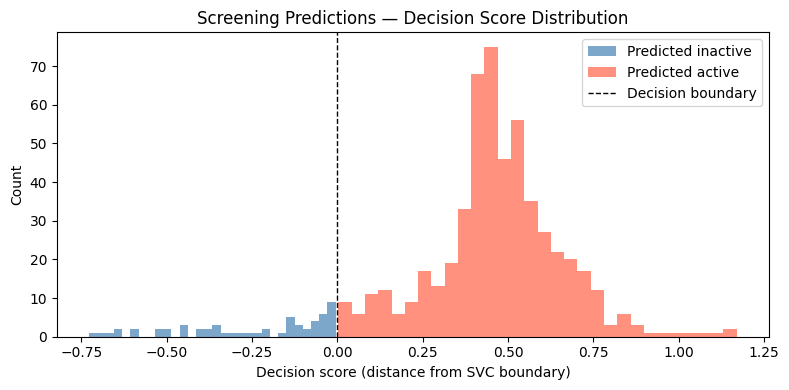

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

# Histogram split by predicted class
ax.hist(results.loc[results['predicted']==0, 'decision_score'],
        bins=30, color='steelblue', alpha=0.7, label='Predicted inactive')
ax.hist(results.loc[results['predicted']==1, 'decision_score'],
        bins=30, color='tomato', alpha=0.7, label='Predicted active')
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Decision boundary')
ax.set_xlabel('Decision score (distance from SVC boundary)')
ax.set_ylabel('Count')
ax.set_title('Screening Predictions — Decision Score Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/screening_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Predictions

In [21]:
os.makedirs('../results/predictions', exist_ok=True)

# Save all predictions
results.to_csv('../results/predictions/screening_predictions.csv', index=False)

# Save active-only subset for Task 7 PharmGKB lookup
actives.to_csv('../results/predictions/predicted_actives.csv', index=False)

print(f'Saved: results/predictions/screening_predictions.csv  ({len(results)} compounds)')
print(f'Saved: results/predictions/predicted_actives.csv       ({len(actives)} predicted actives)')

Saved: results/predictions/screening_predictions.csv  (591 compounds)
Saved: results/predictions/predicted_actives.csv       (533 predicted actives)
